# Schelling Model with mesa

> Computational Analysis of Social Complexity



**Prerequisites**

- Python Basics (from week 2)
- Python Types (from week 2)
- ABM intro

**Outcomes**

- Learn to use the Python REPL for running interactive ABM visualizations
- Implement the Schelling segregation model using mesa

**References**

- [mesa documentation](https://mesa.readthedocs.io/)
- [QuantEcon lecture](https://python.quantecon.org/schelling.html)

## Review Schelling Model

- Recall the components of the Schelling segregation model
- Environment: 25x25 grid of single family dwellings
- Agents with properties:
  - location (x,y) coordinate for current home
  - type: orange or blue. Fixed over time. 250 of each
  - happiness: 0 if less than $N$ of neighbors are of same type, 1 otherwise
- Rules:
  - Agents choose to move to unoccupied grid point if unhappy

> Note neighbors for a particular cell are the the 8 other cells surrounding the cell of interest. Corner or edge cells have less than 8 neighbors

## mesa

- We are now ready to get started implementing the Schelling segregation model in Python
- We'll use [mesa](https://mesa.readthedocs.io/), a widely used, pure-Python ABM toolkit
- mesa gives us three main building blocks that map directly onto the ABM components we studied:
  - `mesa.Agent`: base class for individual agents
  - `mesa.space` (e.g. `SingleGrid`, `MultiGrid`, `ContinuousSpace`, `NetworkGrid`): environments agents live in
  - `mesa.Model`: ties agents and environment together and drives the rules forward one step at a time
- It also ships a `DataCollector` for recording agent/model data as the simulation runs, which we'll use heavily below

## Schelling in mesa

- Let's now implement the Schelling Segregation model in mesa
- The first thing we'll need to do is define our Agent
- The recommended way to do this is to create a new Python class that subclasses `mesa.Agent`
- Subclassing `mesa.Agent` will ensure a few things:
    - The instance gets a unique `unique_id` and a reference to the `model` it lives in
    - The instance has a `pos` attribute that the grid maintains when we place/move the agent
    - A Python class can bundle both the agent's state *and* its behavior (its `step` method) together

In [1]:
# load up the packages we need for this example
import mesa
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

In [2]:
class SchellingAgent(mesa.Agent):
    """An agent living on the Schelling grid.

    Attributes
    ----------
    group : int
        The group of the agent, determines happiness as it interacts with
        neighbors. 1: blue, 2: orange
    is_happy : bool
        Whether the agent is happy in its current position (True = happy)
    """

    def __init__(self, model, group):
        super().__init__(model)
        self.group = group
        self.is_happy = False

    def step(self):
        want = self.model.wanted_neighbors
        neighbors = self.model.grid.get_neighbors(
            self.pos, moore=True, include_center=False
        )
        have = sum(1 for n in neighbors if n.group == self.group)
        self.is_happy = have >= want
        if not self.is_happy:
            self.model.grid.move_to_empty(self)

- We can see the complete structure of the `SchellingAgent` class using `inspect.signature`

In [3]:
import inspect

inspect.signature(SchellingAgent.__init__)

<Signature (self, model, group)>

### Schelling Environment

- Our Schelling environment will be one of the built-in mesa spaces
- We'll use `mesa.space.SingleGrid`, which guarantees at most one agent per cell -- exactly the "single family dwelling" assumption of the model

In [4]:
environment = mesa.space.SingleGrid(25, 25, torus=False)

### Rules

- The last part of our ABM that we need to specify is the rules for how agents respond to the environment and state
  - Our rule is that agents will choose to move to an empty grid space if they have less than `wanted_neighbors` neighbors of the same group
- In mesa, these rules live in the `step` method of our `SchellingAgent` class (defined above)
- We make use of a couple of helper methods provided by mesa's `SingleGrid`:
  - `move_to_empty`: move a single agent to a random empty place in the environment. This modifies the `pos` attribute of the agent
  - `get_neighbors`: return a list of all neighbors of a particular cell. This queries the `pos` attribute of all agents

In [5]:
print(inspect.getsource(SchellingAgent.step))

    def step(self):
        want = self.model.wanted_neighbors
        neighbors = self.model.grid.get_neighbors(
            self.pos, moore=True, include_center=False
        )
        have = sum(1 for n in neighbors if n.group == self.group)
        self.is_happy = have >= want
        if not self.is_happy:
            self.model.grid.move_to_empty(self)



### Combining Agents, Environment, and Rules

- We now need to create a subclass of `mesa.Model`
- Our model's `__init__` needs to build our environment, create and place our agents, and store any additional properties (like `wanted_neighbors`)
- These additional properties belong to the model, and can be thought of as parameters that should be calibrated
- The model's `step` method advances every agent by one time period (this is analogous to Agents.jl's `agent_step!` being called on every agent)

In [6]:
class SchellingModel(mesa.Model):
    def __init__(
        self,
        width=25,
        height=25,
        num_agents_per_group=250,
        wanted_neighbors=4,
        rng=6318,
    ):
        super().__init__(rng=rng)
        self.wanted_neighbors = wanted_neighbors
        self.grid = mesa.space.SingleGrid(width, height, torus=False)

        for group in (1, 2):
            for _ in range(num_agents_per_group):
                agent = SchellingAgent(self, group)
                pos = self.random.choice(sorted(self.grid.empties))
                self.grid.place_agent(agent, pos)

        self.datacollector = mesa.DataCollector(
            model_reporters={"n_happy": lambda m: sum(a.is_happy for a in m.agents)},
            agent_reporters={"pos": "pos", "is_happy": "is_happy", "group": "group"},
        )
        self.datacollector.collect(self)

    def step(self):
        self.agents.shuffle_do("step")
        self.datacollector.collect(self)

### Add Agents

- The `SchellingModel.__init__` method above already handles adding agents to the environment
- It uses `self.random.choice` over the grid's `empties` set to place non-overlapping agents, which is the Python equivalent of Agents.jl's `add_agent_single!`
- So that we can run many experiments, we'll create a helper function that returns a fresh model

In [7]:
def init_schelling(num_agents_per_group=250, wanted_neighbors=4):
    return SchellingModel(
        num_agents_per_group=num_agents_per_group,
        wanted_neighbors=wanted_neighbors,
    )


model = init_schelling()

### Running the Model

- To run our model, we need to step forward in time
- We do this by calling the `step` method on our model
- This method will iterate over all the agents in the model (in random order, via `shuffle_do`) and call each agent's `step` method

In [8]:
# advance one step
model.step()

In [9]:
# advance three steps
for _ in range(3):
    model.step()

- We can also collect all of the recorded data at once
- The `DataCollector` we attached to the model records `pos`, `is_happy`, and `group` for every agent, every step
- The output is a pandas `DataFrame` with all the data

In [10]:
model = init_schelling()
for _ in range(10):
    model.step()

data = model.datacollector.get_agent_vars_dataframe()
data

pos  is_happy  group
Step AgentID                           
0.0  1          (0, 0)     False      1
     2         (16, 7)     False      1
     3          (5, 2)     False      1
     4         (13, 9)     False      1
     5         (5, 12)     False      1
...                ...       ...    ...
10.0 496      (18, 22)      True      2
     497      (14, 16)      True      2
     498      (12, 19)      True      2
     499       (2, 15)     False      2
     500        (5, 1)      True      2

[5500 rows x 3 columns]

### Visualizing the Agents

- One of the more instructive (and fun!) parts of agent based modeling is visualizing the data
- To do this visualization we will write a small helper function using matplotlib that scatters each agent at its grid position, colored by group

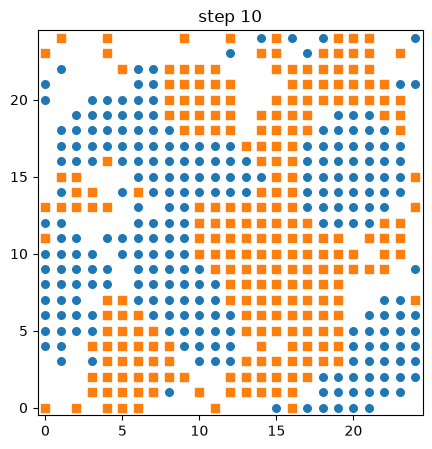

In [11]:
def plot_model(model, ax=None, title=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    colors = {1: "tab:blue", 2: "tab:orange"}
    markers = {1: "o", 2: "s"}
    for group in (1, 2):
        xs = [a.pos[0] for a in model.agents if a.group == group]
        ys = [a.pos[1] for a in model.agents if a.group == group]
        ax.scatter(xs, ys, c=colors[group], marker=markers[group], s=30)
    ax.set_xlim(-0.5, model.grid.width - 0.5)
    ax.set_ylim(-0.5, model.grid.height - 0.5)
    ax.set_aspect("equal")
    ax.set_title(title or f"step {model.steps}")
    return ax


plot_model(model)
plt.show()

### Animating the Agents

- We can also create a video that animates our agents moving throughout the system
- We do this by stepping the model forward, capturing a snapshot after each step, and stitching the snapshots into a `matplotlib.animation.FuncAnimation`
- Saving the animation to an mp4 file requires ffmpeg to be installed, exactly as Agents.jl's `abmvideo` requires an external video backend

In [12]:
model = init_schelling()

fig, ax = plt.subplots(figsize=(5, 5))


def update(frame):
    ax.clear()
    if frame > 0:
        model.step()
    plot_model(model, ax=ax, title="Schelling's segregation model")
    return ax.collections


anim = animation.FuncAnimation(fig, update, frames=20, blit=False)
anim.save("schelling.mp4", writer=animation.FFMpegWriter(fps=4))
plt.close(fig)

### Interactive Application

- mesa's Python-native tooling doesn't ship a REPL-based interactive explorer the way Agents.jl's `abmexploration` does
- Instead, we can get very similar interactivity in a Jupyter notebook using `ipywidgets.interact`
- We give `interact` a function that:
  - takes `wanted_neighbors` as an argument
  - builds a fresh model, runs it forward some number of steps, and plots the result
- `ipywidgets` automatically creates a slider for the `wanted_neighbors` parameter and re-runs the function whenever it changes

In [13]:
from ipywidgets import interact


@interact(wanted_neighbors=(0, 8, 1), n_steps=(0, 30, 1))
def explore_schelling(wanted_neighbors=4, n_steps=10):
    model = init_schelling(wanted_neighbors=wanted_neighbors)
    n_happy = [model.datacollector.model_vars["n_happy"][-1]]
    for _ in range(n_steps):
        model.step()
        n_happy.append(model.datacollector.model_vars["n_happy"][-1])

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    plot_model(model, ax=axes[0], title=f"step {model.steps}")
    axes[1].plot(n_happy)
    axes[1].set_xlabel("step")
    axes[1].set_ylabel("n_happy")
    axes[1].set_title("Number of happy agents over time")
    plt.tight_layout()
    plt.show()

interactive(children=(IntSlider(value=4, description='wanted_neighbors', max=8), IntSlider(value=10, descripti…

## Running our Interactive Schelling Model

- Running the cell above inside a Jupyter notebook (or JupyterLab) will display a live slider for `wanted_neighbors` and `n_steps`
- Adjusting a slider re-runs `explore_schelling` and redraws the grid and happiness chart in real-time
- `ipywidgets.interact` works directly inside the Jupyter environment you are already using -- no separate terminal session required

## Real-World Implications

- Schelling's model was groundbreaking for urban planning and social policy
- Key insight: segregation doesn't require intense prejudice - even mild preferences for similar neighbors create strong patterns
- Applications beyond racial segregation:
  - Income clustering in neighborhoods
  - Social media echo chambers and political polarization
  - Clustering in high school cafeterias
  - Academic discipline segregation in universities
- Model limitations: Reality includes housing costs, school quality, employment access, historical policies
- Policy implication: Simply reducing prejudice may not eliminate segregation - structural interventions may be needed

## Exercises

### Exercise 1: Parameter Sensitivity Analysis

Using the interactive app or by modifying the code, explore how different `wanted_neighbors` values affect segregation:

1. Run the model with `wanted_neighbors = 1` (agents want just 1 similar neighbor)
   - Observe the final pattern. Is there segregation?
2. Run with `wanted_neighbors = 3` (moderate preference)
   - How does the pattern differ? How many steps to stability?
3. Run with `wanted_neighbors = 6` (strong preference)
   - What happens? Do all agents become happy?
4. Document your findings:
   - At what threshold does segregation become noticeable?
   - What happens when the threshold is too high?
   - How does empty space (less than 500 agents total) affect the patterns?

### Exercise 2: Model Extensions

Modify the Schelling model to explore these variations:

1. **Three groups instead of two**:
   - Add a third group (e.g., green agents)
   - What patterns emerge with three groups?
   - Hint: Modify the `init_schelling` function to have `for group in (1, 2, 3)`

2. **Asymmetric populations**:
   - Try 400 agents of group 1 and 100 agents of group 2
   - Does the minority group cluster more tightly?
   - What happens to the majority group's distribution?

3. **Different happiness thresholds per group**:
   - Modify so group 1 wants 3 similar neighbors, group 2 wants 5
   - Which group ends up more segregated?
   - What does this suggest about tolerance and outcomes?

4. **Distance-based happiness** (Advanced):
   - Instead of just counting similar neighbors, weight them by distance
   - Immediate neighbors count as 1.0, diagonal neighbors as 0.7
   - How does this change the segregation patterns?

Choose at least one modification to implement and document your observations.